In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/cruorvult/botify-dataset/tmp/data.json.1
/kaggle/input/datasets/cruorvult/botify-dataset/tmp/data.json
/kaggle/input/datasets/cruorvult/botify-dataset/tmp/data.json.2
/kaggle/input/datasets/cruorvult/botify-dataset/tmp/data.json.3
/kaggle/input/datasets/cruorvult/botify-dataset/tmp/tracks.json
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.23
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.1
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.17
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.21
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.11
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.7
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json.4
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json16
/kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp/data.json25
/kaggle/in

In [2]:
!pip install -q rectools[torch] lightning-fabric

In [3]:
import os
import glob
import json

import numpy as np
import pandas as pd

from rectools import Columns
from rectools.dataset import Dataset
from rectools.models import BERT4RecModel, PopularModel
from rectools.metrics import NDCG, HitRate
from lightning_fabric import seed_everything

os.environ['CUBLAS_WORKSPACE_CONFIG'] = ':4096:8'
SEED_VALUE = 42
seed_everything(SEED_VALUE, workers=True)

Seed set to 42


42

## 1. Load listening events

In [4]:
from pathlib import Path
PROJECT_ROOT = Path('/kaggle/input/datasets/cruorvult/botify-dataset-v3')
RAW_DATA_DIR = PROJECT_ROOT / 'tmp'

listening_paths = sorted(glob.glob(str(RAW_DATA_DIR / 'data.json*')))
print(f'Found {len(listening_paths)} listening files in {RAW_DATA_DIR}')

listen_log = pd.concat(
    [pd.read_json(path, lines=True)[['user', 'track', 'timestamp', 'time']] for path in listening_paths],
    ignore_index=True,
)

listen_log = listen_log.sort_values(['timestamp', 'user', 'track']).reset_index(drop=True)
print(f'Raw events: {listen_log.shape[0]:,}')
listen_log.head()

Found 26 listening files in /kaggle/input/datasets/cruorvult/botify-dataset-v3/tmp
Raw events: 7,195,212


,user,track,timestamp,time
0,5637,13787,2026-04-25 18:51:29.330,1.00
1,5637,13787,2026-04-25 18:51:29.330,1.00
2,5637,13787,2026-04-25 18:51:29.332,1.00
3,5637,13787,2026-04-25 18:51:29.332,1.00
4,5637,483,2026-04-25 18:51:29.335,0.39


## Listening time distribution

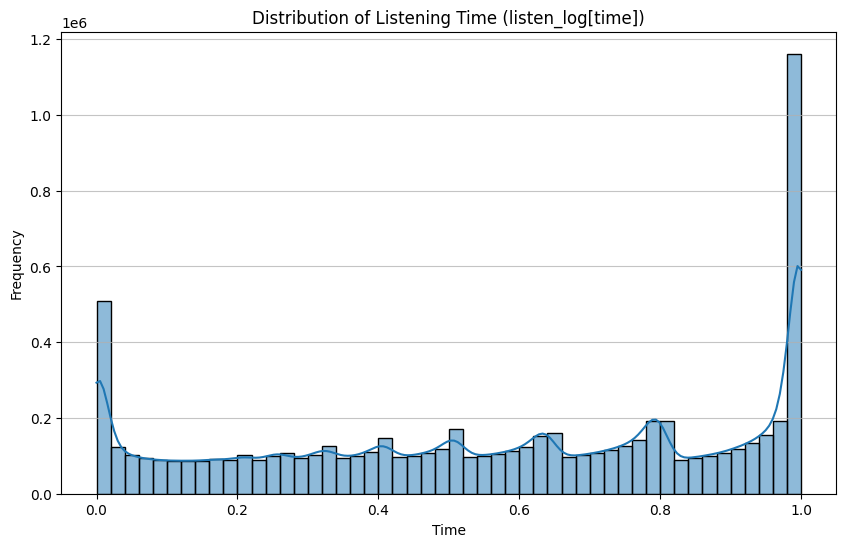

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(listen_log['time'], bins=50, kde=True)
plt.title('Distribution of Listening Time (listen_log[time])')
plt.xlabel('Time')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.show()

We see high peaks at the distribution edges 

In [30]:
listen_log.groupby('user').count()['time'].max()

1866

In [9]:
# Hybrid positive feedback rule.
# Strong listens are kept deterministically, while weaker listens are sampled
# according to a smooth probability derived from relative listening duration.
ALWAYS_KEEP_TOP_TAIL = listen_log['time'].median() + listen_log['time'].std()/2
LISTENING_PROBABILITY_TEMPERATURE = 2
MIN_SAMPLING_PROBABILITY = 1e-3

sampling_rng = np.random.default_rng(SEED_VALUE)

strong_listen_cutoff = listen_log['time'].quantile(ALWAYS_KEEP_TOP_TAIL)
strong_listen_mask = listen_log['time'] >= strong_listen_cutoff

# Convert listening completion into a sampling probability.
# The power transform is intentionally strict: 0.5 -> 0.125, 0.8 -> 0.512,
# 0.95 -> 0.857. This keeps high-intent listens much more often than noisy ones.
listen_sample_probability = (
    listen_log['time']
    .clip(lower=MIN_SAMPLING_PROBABILITY, upper=1.0)
    ** LISTENING_PROBABILITY_TEMPERATURE
)

weak_sample_mask = sampling_rng.random(len(listen_log)) < listen_sample_probability
hybrid_positive_mask = strong_listen_mask | weak_sample_mask

positive_events = listen_log.loc[
    hybrid_positive_mask,
    ['user', 'track', 'timestamp', 'time'],
].copy()

# Deduplicate repeated selected listens while keeping the latest timestamp and
# the strongest observed completion as the implicit interaction weight.
positive_events = (
    positive_events
    .sort_values(['user', 'track', 'timestamp'])
    .groupby(['user', 'track'], as_index=False)
    .agg(timestamp=('timestamp', 'max'), time=('time', 'max'))
    .sort_values('timestamp')
    .reset_index(drop=True)
)

positive_interactions = positive_events.rename(columns={
    'user': Columns.User,
    'track': Columns.Item,
    'timestamp': Columns.Datetime,
    'time': Columns.Weight,
})

kept_share = positive_interactions.shape[0] / listen_log.shape[0]
print(f'Always-keep completion quantile: {ALWAYS_KEEP_TOP_TAIL:.2f}')
print(f'Always-keep completion cutoff: {strong_listen_cutoff:.4f}')
print(f'Sampling temperature: {LISTENING_PROBABILITY_TEMPERATURE:.1f}')
print(f'Raw events marked strong: {strong_listen_mask.sum():,}')
print(f'Raw events sampled by probability: {weak_sample_mask.sum():,}')
print(f'Positive interactions after deduplication: {positive_interactions.shape[0]:,} / {listen_log.shape[0]:,} ({kept_share:.2%})')
positive_interactions.head()


Always-keep completion quantile: 0.78
Always-keep completion cutoff: 0.9200
Sampling temperature: 2.0
Raw events marked strong: 1,641,838
Raw events sampled by probability: 3,130,782
Positive interactions after deduplication: 1,310,512 / 7,195,212 (18.21%)


,user_id,item_id,datetime,weight
0,5637,483,2026-04-25 18:51:29.335,0.39
1,5637,13789,2026-04-25 18:51:29.349,0.51
2,5637,475,2026-04-25 18:51:29.372,0.71
3,5637,771,2026-04-25 18:51:29.376,0.58
4,5341,5437,2026-04-25 18:51:29.430,0.34


## 3. Time-based validation split

In [10]:
TRAIN_FRACTION = 0.90
cut_position = int(TRAIN_FRACTION * len(positive_interactions))

model_train_events = positive_interactions.iloc[:cut_position].copy()
model_valid_events = positive_interactions.iloc[cut_position:].copy()

known_users = set(model_train_events[Columns.User])
known_items = set(model_train_events[Columns.Item])
model_valid_events = model_valid_events[
    model_valid_events[Columns.User].isin(known_users)
    & model_valid_events[Columns.Item].isin(known_items)
].copy()

print('train:', model_train_events.shape, 'valid:', model_valid_events.shape)

train: (1179460, 4) valid: (131052, 4)


## 4. Build item features

In [11]:
track_catalog = (
    pd.read_json(RAW_DATA_DIR / 'tracks.json', lines=True)
    .drop_duplicates(subset=['track'])
    .rename(columns={'track': Columns.Item})
)

active_tracks = track_catalog.loc[
    track_catalog[Columns.Item].isin(model_train_events[Columns.Item])
].copy()

def as_feature_frame(source_df, column_name, feature_name, explode=False):
    feature_df = source_df[[Columns.Item, column_name]].copy()
    if explode:
        feature_df = feature_df.explode(column_name)
    feature_df = feature_df.rename(columns={Columns.Item: 'id', column_name: 'value'})
    feature_df['feature'] = feature_name
    return feature_df.dropna(subset=['value'])

track_side_features = pd.concat(
    [
        as_feature_frame(active_tracks, 'artist_id', 'artist'),
        as_feature_frame(active_tracks, 'genres', 'genre', explode=True),
        as_feature_frame(active_tracks, 'mood', 'mood'),
        as_feature_frame(active_tracks, 'artist_country', 'country'),
        as_feature_frame(active_tracks, 'year', 'release_year'),
    ],
    ignore_index=True,
)

print(f'Catalog tracks: {track_catalog.shape[0]:,}; tracks used for training: {active_tracks.shape[0]:,}')
track_side_features.head()

Catalog tracks: 16,198; tracks used for training: 16,198


,id,value,feature
0,0,0,artist
1,1,0,artist
2,2,0,artist
3,3,0,artist
4,4,0,artist


In [12]:
train_rectools_data = Dataset.construct(
    interactions_df=model_train_events,
    item_features_df=track_side_features,
    cat_item_features=['artist', 'genre', 'mood', 'country', 'release_year'],
)

## 5. Train baseline and BERT4Rec

In [23]:
sequence_encoder = BERT4RecModel(
    session_max_len=300,      
    mask_prob=0.2,            
    loss="softmax",
    n_factors=96,             
    n_blocks=2,               
    n_heads=4,
    dropout_rate=0.2,        
    lr=1e-3,                  
    batch_size=128,
    epochs=200,               
    verbose=1,
    deterministic=True,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs


In [24]:
sequence_encoder.fit(train_rectools_data)

/usr/local/lib/python3.12/dist-packages/rectools/dataset/identifiers.py:60: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unq_values = pd.unique(values)
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='item_net_block_types', input_value=('rectools.models.nn.item...net.CatFeaturesItemNet'), input_type=tuple])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
2026-04-28 10:49:06.430816: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [32]:
sequence_encoder = BERT4RecModel(
    session_max_len=256,
    mask_prob=0.2,
    loss="softmax",
    n_factors=128,
    n_blocks=2,
    n_heads=4,
    dropout_rate=0.15,
    lr=7e-4,
    batch_size=128,
    epochs=160,
    verbose=1,
    deterministic=True,
)
sequence_encoder.fit(train_rectools_data)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/rectools/dataset/identifiers.py:60: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unq_values = pd.unique(values)
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='item_net_block_types', input_value=('rectools.models.nn.item...net.CatFeaturesItemNet'), input_type=tuple])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name        | Type          

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=160` reached.


In [ ]:
# sequence_encoder = BERT4RecModel(
#     session_max_len=256,
#     mask_prob=0.2,
#     loss="softmax",
#     n_factors=192,
#     n_blocks=2,
#     n_heads=6,
#     dropout_rate=0.15,
#     lr=5e-4,
#     batch_size=128,
#     epochs=160,
#     verbose=1,
#     deterministic=True,
# )

In [49]:
top_popular_model = PopularModel()
top_popular_model.fit(train_rectools_data)

validation_users = model_valid_events[Columns.User].unique()
popular_validation_recs = top_popular_model.recommend(
    users=validation_users,
    dataset=train_rectools_data,
    k=10,
    filter_viewed=True,
)

bert_validation_recs = sequence_encoder.recommend(
    users=validation_users,
    dataset=train_rectools_data,
    k=10,
    filter_viewed=True,
    on_unsupported_targets='warn',
)

In [50]:
quality_metrics = {'ndcg@10': NDCG(k=10), 'hit_rate@10': HitRate(k=10)}
validation_predictions = {
    'popular_baseline': popular_validation_recs,
    'bert4rec_sequence': bert_validation_recs,
}

metric_rows = []
for metric_name, metric in quality_metrics.items():
    for model_name, reco_frame in validation_predictions.items():
        metric_rows.append({
            'model': model_name,
            'metric': metric_name,
            'value': metric.calc(reco_frame, interactions=model_valid_events),
        })

(
    pd.DataFrame(metric_rows)
    .pivot(index='model', columns='metric', values='value')
    .sort_values('ndcg@10', ascending=False)
)

metric,hit_rate@10,ndcg@10
model,,
bert4rec_sequence,0.609567,0.256922
popular_baseline,0.105747,0.025644


In [14]:
quality_metrics = {'ndcg@10': NDCG(k=10), 'hit_rate@10': HitRate(k=10)}
validation_predictions = {
    'popular_baseline': popular_validation_recs,
    'bert4rec_sequence': bert_validation_recs,
}

metric_rows = []
for metric_name, metric in quality_metrics.items():
    for model_name, reco_frame in validation_predictions.items():
        metric_rows.append({
            'model': model_name,
            'metric': metric_name,
            'value': metric.calc(reco_frame, interactions=model_valid_events),
        })

(
    pd.DataFrame(metric_rows)
    .pivot(index='model', columns='metric', values='value')
    .sort_values('ndcg@10', ascending=False)
)

metric,hit_rate@10,ndcg@10
model,,
bert4rec_sequence,0.281677,0.078728
popular_baseline,0.028765,0.011175


## 6. Generate item-to-item recommendations

In [11]:
# from rectools.models.nn import BERT4RecModel
model_path = '/kaggle/input/models/cruorvult/bert4rec-sigma-time-filter/pytorch/default/1/bert4rec_sigma_time_filter (1).pkl'
sequence_encoder = BERT4RecModel.load(model_path)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
2026-04-29 20:28:20.290800: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777494500.473291     127 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777494500.524015     127 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1777494500.943810     127 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

In [12]:
candidate_anchor_items = (
    model_train_events.groupby(Columns.Item)
    .size()
    .sort_values(ascending=False)
    .index
    .to_list()
)

raw_i2i_neighbors = sequence_encoder.recommend_to_items(
    target_items=candidate_anchor_items,
    dataset=train_rectools_data,
    k=100,
    filter_itself=True,
    items_to_recommend=None,
    on_unsupported_targets='warn',
)
raw_i2i_neighbors.head()

/usr/local/lib/python3.12/dist-packages/rectools/models/base.py:728: UserWarning: 
                Model `<class 'rectools.models.nn.transformers.bert4rec.BERT4RecModel'>` doesn't support recommendations for cold items,
                but some of given items are cold: they are not in the `dataset.item_id_map`
            
  warnings.warn(explanation)


,target_item_id,item_id,score,rank
0,7094,6109,0.912205,1
1,7094,5499,0.904108,2
2,7094,7412,0.901403,3
3,7094,4939,0.866822,4
4,7094,2495,0.862017,5


## 7. Diversify by excluding same-artist neighbours (BERT only) 

In [1]:
## Blended model

In [16]:
artist_lookup = active_tracks[[Columns.Item, 'artist_id']].drop_duplicates()

diverse_i2i_neighbors = raw_i2i_neighbors.merge(
    artist_lookup.rename(columns={Columns.Item: 'target_item_id', 'artist_id': 'anchor_artist_id'}),
    on='target_item_id',
    how='inner',
)

diverse_i2i_neighbors = diverse_i2i_neighbors.merge(
    artist_lookup.rename(columns={'artist_id': 'neighbor_artist_id'}),
    on=Columns.Item,
    how='inner',
)

diverse_i2i_neighbors = (
    diverse_i2i_neighbors
    .loc[lambda frame: frame['anchor_artist_id'] != frame['neighbor_artist_id']]
    .drop(columns=['anchor_artist_id', 'neighbor_artist_id'])
    .sort_values(['target_item_id', 'rank'])
    .groupby('target_item_id', as_index=False)
    .head(100)
)

diverse_i2i_neighbors['rank'] = diverse_i2i_neighbors.groupby('target_item_id').cumcount() + 1
print('raw rows:', raw_i2i_neighbors.shape[0], 'diverse rows:', diverse_i2i_neighbors.shape[0])
diverse_i2i_neighbors.head()

raw rows: 1617900 diverse rows: 1558279


,target_item_id,item_id,score,rank
62901,0,7133,0.879988,1
62902,0,7134,0.878076,2
62906,0,7104,0.774133,3
62907,0,1031,0.772506,4
62909,0,7118,0.742361,5


## 8. (BERT only) Export JSONL

In [17]:
SAVING_FOLDER = Path('/kaggle/working')
def save_i2i_jsonl(recommendation_frame, output_path):
    output_path = Path(output_path)
    with output_path.open('w') as output_file:
        for anchor_id, group in recommendation_frame.groupby('target_item_id'):
            ordered_recs = group.sort_values('rank')[Columns.Item].tolist()
            output_file.write(json.dumps({'item_id': anchor_id, 'recommendations': ordered_recs}) + '\n')

EXPORT_PATH = SAVING_FOLDER / 'bert4rec_more_data_sigma_weight_100.jsonl'
save_i2i_jsonl(diverse_i2i_neighbors, EXPORT_PATH)
print(EXPORT_PATH)

/kaggle/working/bert4rec_more_data_sigma_weight_100.jsonl


## Multiple models approach

## 9. Train SasRec and prepare candidates

In [64]:
from rectools.models.nn.transformers.sasrec import SASRecModel

sasrec_encoder = SASRecModel(
    session_max_len=128,
    loss="sampled_softmax",
    n_negatives=256,
    n_factors=96,
    n_blocks=1,
    n_heads=3,
    dropout_rate=0.2,
    lr=1e-3,
    batch_size=256,
    epochs=40,
    verbose=1,
    deterministic=True,
)

sasrec_encoder.fit(train_rectools_data)



GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/rectools/dataset/identifiers.py:60: FutureWarning: unique with argument that is not not a Series, Index, ExtensionArray, or np.ndarray is deprecated and will raise in a future version.
  unq_values = pd.unique(values)
/usr/local/lib/python3.12/dist-packages/pydantic/main.py:464: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `str` - serialized value may not be as expected [field_name='item_net_block_types', input_value=('rectools.models.nn.item...net.CatFeaturesItemNet'), input_type=tuple])
  return self.__pydantic_serializer__.to_python(
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name        | Type          

Training: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=40` reached.


In [19]:
from rectools.models.nn.transformers.sasrec import SASRecModel
sasrec_encoder = SASRecModel.load('/kaggle/input/models/cruorvult/sasrec-sigma-time-filter/pytorch/default/1/sasrec_sigma_time_filter.pkl')

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/trainer/configuration_validator.py:70: You defined a `validation_step` but have no `val_dataloader`. Skipping val loop.
Restoring states from the checkpoint path at /tmp/tmpybgx67z3
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]

  | Name        | Type                     | Params | Mode 
-----------------------------------------------------------------
0 | torch_model | TransformerTorchBackbone | 1.9 M  | train
-----------------------------------------------------------------
1.9 M     Trainable params
0         Non-trainable params
1.9 M     Total params
7.607     Total estimated model params size (MB)
26        Modules in train mode
0         Modules in eval mode
Restored all states from the checkpoint at /tmp/tmpybgx67z3
/usr/local/lib/python3.12/dist-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance

In [65]:
sasrec_validation_recs = sasrec_encoder.recommend(
    users=validation_users,
    dataset=train_rectools_data,
    k=10,
    filter_viewed=True,
    on_unsupported_targets='warn',
)

quality_metrics = {'ndcg@10': NDCG(k=10), 'hit_rate@10': HitRate(k=10)}
validation_predictions = {
    'popular_baseline': popular_validation_recs,
    'bert4rec_sequence': bert_validation_recs,
    'sasrec_validation_recs': sasrec_validation_recs,
}

metric_rows = []
for metric_name, metric in quality_metrics.items():
    for model_name, reco_frame in validation_predictions.items():
        metric_rows.append({
            'model': model_name,
            'metric': metric_name,
            'value': metric.calc(reco_frame, interactions=model_valid_events),
        })

(
    pd.DataFrame(metric_rows)
    .pivot(index='model', columns='metric', values='value')
    .sort_values('ndcg@10', ascending=False)
)

metric,hit_rate@10,ndcg@10
model,,
sasrec_validation_recs,0.638025,0.261031
bert4rec_sequence,0.609567,0.256922
popular_baseline,0.105747,0.025644


In [20]:
# =============================
# SASRec I2I recommendations
# =============================

I2I_TOPK_RAW = 100

all_tracks = positive_interactions[Columns.Item].unique()

sasrec_i2i_recs = sasrec_encoder.recommend_to_items(
    target_items=all_tracks,
    dataset=train_rectools_data,
    k=I2I_TOPK_RAW,
    filter_itself=True,
    on_unsupported_targets="ignore",
)

sasrec_i2i_neighbors = sasrec_i2i_recs.rename(columns={
    Columns.TargetItem: "target_item_id",
    Columns.Score: "sasrec_score",
}).copy()

sasrec_i2i_neighbors = sasrec_i2i_neighbors[
    ["target_item_id", Columns.Item, "sasrec_score"]
]

sasrec_i2i_neighbors.head()

,target_item_id,item_id,sasrec_score
0,483,13580,0.662684
1,483,479,0.651811
2,483,480,0.648040
3,483,6270,0.643589
4,483,482,0.642607


In [21]:
print(track_side_features.columns)
print(positive_interactions.columns)

Index(['id', 'value', 'feature'], dtype='object')
Index(['user_id', 'item_id', 'datetime', 'weight'], dtype='object')


In [ ]:
# Fallback: use item ids as artificial target users/items if recommend_to_items is unavailable

sasrec_i2i_neighbors = []

for item_id in tqdm(all_tracks, desc="SASRec I2I"):
    try:
        recs = sasrec_encoder.recommend_to_items(
            target_items=[item_id],
            dataset=train_rectools_data,
            k=I2I_TOPK_RAW,
            filter_itself=True,
            on_unsupported_targets="ignore",
        )
        sasrec_i2i_neighbors.append(recs)
    except Exception:
        continue

sasrec_i2i_neighbors = pd.concat(sasrec_i2i_neighbors, ignore_index=True)

sasrec_i2i_neighbors = sasrec_i2i_neighbors.rename(columns={
    Columns.TargetItem: "target_item_id",
    Columns.Score: "sasrec_score",
})[["target_item_id", Columns.Item, "sasrec_score"]]

In [70]:
sasrec_encoder.save("sasrec_sigma_time_filter.pkl")

24011517

## Diversity

In [22]:
    
    import os
    
    OUTPUT_DIR = "i2i_pickles"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    # Save BERT4Rec neighbors
    if 'raw_i2i_neighbors' in globals():
        raw_i2i_neighbors.to_pickle(f"{OUTPUT_DIR}/bert4rec_i2i_neighbors.pkl")
    
    # Save SASRec neighbors
    if 'sasrec_i2i_neighbors' in globals():
        sasrec_i2i_neighbors.to_pickle(f"{OUTPUT_DIR}/sasrec_i2i_neighbors.pkl")
    
    # Save co-occurrence neighbors
    if 'cooc_i2i_neighbors' in globals():
        cooc_i2i_neighbors.to_pickle(f"{OUTPUT_DIR}/cooc_i2i_neighbors.pkl")
    
    # Save blended candidates (before MMR)
    if 'blended_i2i_candidates' in globals():
        blended_i2i_candidates.to_pickle(f"{OUTPUT_DIR}/blended_i2i_candidates.pkl")
    
    # Save final reranked neighbors
    if 'diverse_i2i_neighbors' in globals():
        diverse_i2i_neighbors.to_pickle(f"{OUTPUT_DIR}/final_diverse_i2i_neighbors.pkl")
    
    print("Saved all i2i neighbors to:", OUTPUT_DIR)

Saved all i2i neighbors to: i2i_pickles


In [ ]:
# bert = pd.read_pickle("i2i_pickles/bert4rec_i2i_neighbors.pkl")
# sasrec_i2i_neighbors = pd.read_pickle("i2i_pickles/sasrec_i2i_neighbors.pkl")
# cooc = pd.read_pickle("i2i_pickles/cooc_i2i_neighbors.pkl")
# final = pd.read_pickle("i2i_pickles/final_diverse_i2i_neighbors.pkl")

## 10. Co-occurence

In [15]:
from collections import Counter
from tqdm.auto import tqdm

SCORE_COL = getattr(Columns, 'Score', 'score')

# -----------------------------
# 1. Co-occurrence I2I candidates
# -----------------------------
# Music data often benefits from a simple local co-occurrence signal:
# tracks listened by the same user close to each other are useful neighbours.
COOC_CONTEXT_WINDOW = 30
COOC_SESSION_TAIL = 300
MAX_COOC_NEIGHBORS_PER_ITEM = 150

train_events_ordered = model_train_events.sort_values(
    [Columns.User, Columns.Datetime],
    kind='stable',
)

item_popularity = model_train_events.groupby(Columns.Item).size()
pair_counter = Counter()

for _, user_history in tqdm(
    train_events_ordered.groupby(Columns.User, sort=False),
    total=train_events_ordered[Columns.User].nunique(),
    desc='building co-occurrence pairs',
):
    items = user_history[Columns.Item].tolist()[-COOC_SESSION_TAIL:]
    n_items = len(items)
    for pos, anchor_item in enumerate(items):
        left = max(0, pos - COOC_CONTEXT_WINDOW)
        right = min(n_items, pos + COOC_CONTEXT_WINDOW + 1)
        # set() avoids overcounting repeated tracks inside the same local context
        for neighbor_item in set(items[left:pos] + items[pos + 1:right]):
            if anchor_item != neighbor_item:
                pair_counter[(anchor_item, neighbor_item)] += 1

cooc_rows = []
for (anchor_item, neighbor_item), cooc_count in pair_counter.items():
    norm = np.sqrt(item_popularity.get(anchor_item, 1) * item_popularity.get(neighbor_item, 1))
    cooc_rows.append({
        'target_item_id': anchor_item,
        Columns.Item: neighbor_item,
        SCORE_COL: cooc_count / norm,
    })

cooc_i2i_neighbors = pd.DataFrame(cooc_rows)
if not cooc_i2i_neighbors.empty:
    cooc_i2i_neighbors = (
        cooc_i2i_neighbors
        .sort_values(['target_item_id', SCORE_COL], ascending=[True, False])
        .groupby('target_item_id', as_index=False)
        .head(MAX_COOC_NEIGHBORS_PER_ITEM)
    )
    cooc_i2i_neighbors['rank'] = cooc_i2i_neighbors.groupby('target_item_id').cumcount() + 1

print('BERT4Rec candidates:', raw_i2i_neighbors.shape)
print('Co-occurrence candidates:', cooc_i2i_neighbors.shape)

def normalize_i2i_frame(frame, source_name):
    required_cols = ['target_item_id', Columns.Item]
    missing_cols = [col for col in required_cols if col not in frame.columns]
    if missing_cols:
        raise ValueError(f'{source_name}: missing columns {missing_cols}')

    normalized = frame.copy()

    possible_score_cols = [
        SCORE_COL,
        'score',
        'bert_score',
        'sasrec_score',
        'cooc_score',
        'relevance_score',
    ]

    score_col = next(
        (col for col in possible_score_cols if col in normalized.columns),
        None,
    )

    if score_col is None:
        if 'rank' in normalized.columns:
            normalized[SCORE_COL] = 1.0 / normalized['rank'].clip(lower=1)
            score_col = SCORE_COL
        else:
            raise ValueError(
                f'{source_name}: cannot find score column. '
                f'Available columns: {list(normalized.columns)}'
            )

    normalized = normalized[['target_item_id', Columns.Item, score_col]].dropna().copy()
    normalized = normalized.rename(columns={score_col: SCORE_COL})

    group_min = normalized.groupby('target_item_id')[SCORE_COL].transform('min')
    group_max = normalized.groupby('target_item_id')[SCORE_COL].transform('max')
    denom = (group_max - group_min).replace(0, np.nan)

    normalized['source_score'] = (
        (normalized[SCORE_COL] - group_min) / denom
    ).fillna(1.0)

    normalized['source'] = source_name

    return normalized[['target_item_id', Columns.Item, 'source', 'source_score']]

candidate_sources = []
candidate_sources.append(normalize_i2i_frame(raw_i2i_neighbors, 'bert4rec'))

if not cooc_i2i_neighbors.empty:
    candidate_sources.append(normalize_i2i_frame(cooc_i2i_neighbors, 'cooc'))
if 'sasrec_i2i_neighbors' in globals():
    candidate_sources.append(normalize_i2i_frame(sasrec_i2i_neighbors, 'sasrec'))

all_i2i_candidates = pd.concat(candidate_sources, ignore_index=True)

SOURCE_WEIGHTS = {
    'bert4rec': 0.60,
    'cooc': 0.15,
    'sasrec': 0.60,
}

all_i2i_candidates['source_weight'] = all_i2i_candidates['source'].map(SOURCE_WEIGHTS).fillna(1.0)
all_i2i_candidates['weighted_score'] = all_i2i_candidates['source_score'] * all_i2i_candidates['source_weight']

blended_i2i_candidates = (
    all_i2i_candidates
    .groupby(['target_item_id', Columns.Item], as_index=False)['weighted_score']
    .sum()
    .rename(columns={'weighted_score': 'relevance_score'})
)

# Keep only a moderately large candidate pool before diversity reranking.
MAX_BLEND_CANDIDATES_PER_ITEM = 120
blended_i2i_candidates = (
    blended_i2i_candidates
    .sort_values(['target_item_id', 'relevance_score'], ascending=[True, False])
    .groupby('target_item_id', as_index=False)
    .head(MAX_BLEND_CANDIDATES_PER_ITEM)
)

print('Blended candidates:', blended_i2i_candidates.shape)




building co-occurrence pairs:   0%|          | 0/10000 [00:00<?, ?it/s]

BERT4Rec candidates: (1617900, 4)
Co-occurrence candidates: (2429375, 4)
Blended candidates: (1943760, 3)


##  11. MMR diversity reranking

In [16]:
# -----------------------------
# 3. MMR diversity reranking
# -----------------------------
# Hard same-artist filtering is preserved when enough alternatives exist.
# MMR additionally discourages same genre/mood/country and too-similar release years.
TOP_K_I2I = 10
MMR_ALPHA = 0.78                  # higher = more relevance, lower = more diversity
MIN_ALTERNATIVES_AFTER_ARTIST_FILTER = TOP_K_I2I
POPULARITY_PENALTY = 0.02

artist_lookup = active_tracks[[Columns.Item, 'artist_id']].drop_duplicates()
track_meta = active_tracks.set_index(Columns.Item).to_dict('index')
item_pop_log = np.log1p(item_popularity).to_dict()
max_log_pop = max(item_pop_log.values()) if item_pop_log else 1.0


def _as_set(value):
    if isinstance(value, (list, tuple, set)):
        return set(value)
    if pd.isna(value):
        return set()
    return {value}

import re
import numpy as np
import pandas as pd


def parse_release_year(value):
    if pd.isna(value):
        return np.nan

    text = str(value)

    # take first 4-digit year from strings like "1876-1883"
    match = re.search(r"\d{4}", text)
    if match is None:
        return np.nan

    return float(match.group(0))

def content_similarity(item_a, item_b):
    meta_a = track_meta.get(item_a, {})
    meta_b = track_meta.get(item_b, {})

    sim = 0.0

    if meta_a.get("artist") == meta_b.get("artist"):
        sim += 1.00

    if meta_a.get("genre") == meta_b.get("genre"):
        sim += 0.35

    if meta_a.get("mood") == meta_b.get("mood"):
        sim += 0.20

    if meta_a.get("country") == meta_b.get("country"):
        sim += 0.10

    year_a = parse_release_year(meta_a.get("year"))
    year_b = parse_release_year(meta_b.get("year"))

    if pd.notna(year_a) and pd.notna(year_b):
        year_gap = abs(year_a - year_b)
        sim += 0.10 * max(0.0, 1.0 - year_gap / 10.0)

    return sim

def mmr_select_for_anchor(anchor_item, candidate_frame):
    anchor_artist = track_meta.get(anchor_item, {}).get('artist_id')
    candidates = candidate_frame.copy()

    # Penalize very popular tracks a little to reduce generic recommendations.
    candidates['pop_penalty'] = candidates[Columns.Item].map(item_pop_log).fillna(0.0) / max_log_pop
    candidates['adjusted_relevance'] = candidates['relevance_score'] - POPULARITY_PENALTY * candidates['pop_penalty']

    # Preserve the same-artist filter, but use fallback when it leaves too few candidates.
    if anchor_artist is not None:
        candidate_artists = candidates[Columns.Item].map(lambda item: track_meta.get(item, {}).get('artist_id'))
        no_same_artist = candidates.loc[candidate_artists != anchor_artist].copy()
        if len(no_same_artist) >= MIN_ALTERNATIVES_AFTER_ARTIST_FILTER:
            candidates = no_same_artist

    candidates = candidates.sort_values('adjusted_relevance', ascending=False).head(MAX_BLEND_CANDIDATES_PER_ITEM)

    selected_rows = []
    selected_items = []
    remaining = candidates.to_dict('records')

    while remaining and len(selected_rows) < TOP_K_I2I:
        best_idx = None
        best_score = -np.inf

        for idx, row in enumerate(remaining):
            item_id = row[Columns.Item]
            if not selected_items:
                diversity_penalty = content_similarity(anchor_item, item_id)
            else:
                diversity_penalty = max(
                    content_similarity(item_id, chosen_item)
                    for chosen_item in selected_items
                )

            mmr_score = MMR_ALPHA * row['adjusted_relevance'] - (1.0 - MMR_ALPHA) * diversity_penalty
            if mmr_score > best_score:
                best_idx = idx
                best_score = mmr_score

        best_row = remaining.pop(best_idx)
        best_row['mmr_score'] = best_score
        best_row['rank'] = len(selected_rows) + 1
        selected_rows.append(best_row)
        selected_items.append(best_row[Columns.Item])

    return selected_rows

reranked_rows = []
for anchor_item, group in tqdm(
    blended_i2i_candidates.groupby('target_item_id', sort=False),
    total=blended_i2i_candidates['target_item_id'].nunique(),
    desc='MMR reranking',
):
    reranked_rows.extend(mmr_select_for_anchor(anchor_item, group))

mmr_diverse_i2i_neighbors = pd.DataFrame(reranked_rows)

# Keep the old variable name so the export cell below does not need to change.
diverse_i2i_neighbors = mmr_diverse_i2i_neighbors[
    ['target_item_id', Columns.Item, 'relevance_score', 'adjusted_relevance', 'mmr_score', 'rank']
].sort_values(['target_item_id', 'rank']).copy()

print('Final diverse I2I rows:', diverse_i2i_neighbors.shape)
diverse_i2i_neighbors.head()

MMR reranking:   0%|          | 0/16198 [00:00<?, ?it/s]

Final diverse I2I rows: (809900, 6)


,target_item_id,item_id,relevance_score,adjusted_relevance,mmr_score,rank
0,0,7134,1.153406,1.137757,0.788450,1
1,0,1031,1.011967,0.996137,0.671387,2
2,0,7133,1.191553,1.175249,0.577894,3
3,0,1332,0.866072,0.850143,0.520111,4
4,0,7104,0.773972,0.758944,0.473177,5


## 12. (BERT + SasRec + Co-occurences + MMR) Export JSONL

In [5]:
import os
import pandas as pd

OUTPUT_DIR = "i2i_pickles"

def load_if_exists(filename):
    path = os.path.join(OUTPUT_DIR, filename)
    if os.path.exists(path):
        print(f"Loading {filename}")
        return pd.read_pickle(path)
    else:
        print(f"{filename} not found")
        return None


# Load all artifacts
raw_i2i_neighbors = load_if_exists("bert4rec_i2i_neighbors.pkl")
sasrec_i2i_neighbors = load_if_exists("sasrec_i2i_neighbors.pkl")
cooc_i2i_neighbors = load_if_exists("cooc_i2i_neighbors.pkl")
blended_i2i_candidates = load_if_exists("blended_i2i_candidates.pkl")
diverse_i2i_neighbors = load_if_exists("final_diverse_i2i_neighbors.pkl")

Loading bert4rec_i2i_neighbors.pkl
Loading sasrec_i2i_neighbors.pkl
Loading cooc_i2i_neighbors.pkl
Loading blended_i2i_candidates.pkl
Loading final_diverse_i2i_neighbors.pkl


In [6]:
sasrec_i2i_neighbors[:10:]

,target_item_id,item_id,sasrec_score
0,483,13580,0.662684
1,483,479,0.651811
2,483,480,0.648040
3,483,6270,0.643589
4,483,482,0.642607
5,483,13582,0.639287
6,483,481,0.631329
7,483,478,0.625451
8,483,475,0.620629
9,483,6723,0.605443


In [17]:
SAVING_FOLDER = Path('/kaggle/working')
def save_i2i_jsonl(recommendation_frame, output_path):
    output_path = Path(output_path)
    with output_path.open('w') as output_file:
        for anchor_id, group in recommendation_frame.groupby('target_item_id'):
            ordered_recs = group.sort_values('rank')[Columns.Item].tolist()
            output_file.write(json.dumps({'item_id': anchor_id, 'recommendations': ordered_recs}) + '\n')

EXPORT_PATH = SAVING_FOLDER / 'bert4rec_plus_sasrec_50.jsonl'
save_i2i_jsonl(diverse_i2i_neighbors, EXPORT_PATH)
print(EXPORT_PATH)

/kaggle/working/bert4rec_plus_sasrec_50.jsonl


In [60]:
sequence_encoder.save(SAVING_FOLDER / 'bert4rec_sigma_time_filter.pkl')

16520857